
<p style="display:block;text-align:center;font-weight:700;font-size:40px">
  <em>Эссе №5</em>
</p>

<p style="display:block;text-align:center;font-style:italic;font-weight:700;font-size:40px">
  <em>Канал с AWGN: граница Шеннона и реальная BPSK-система</em>
</p>

## **Введение**

В этой работе мы на простой модели набора параллельных AWGN-каналов хотим:

- **понять, почему равномерное распределение мощности между подканалами не является оптимальным**, если уровни шума в этих каналах различаются;

- **численно продемонстрировать алгоритм water-filling** — правило, которое находит такое распределение мощности  $P_i^*$
  при котором суммарная пропускная способность максимальна при фиксированном общем бюджете мощности;

- **визуализировать геометрическую интерпретацию water-filling**, где “уровень воды” заполняет каналы в зависимости от их шумов, а наихудшие каналы могут полностью отключаться;

- **сравнить суммарную пропускную способность** двух стратегий:  
  1) равномерного распределения мощности;  
  2) оптимального water-filling;

- **оценить реальный выигрыш в пропускной способности**, который даёт water-filling (в абсолютных бит/с/Гц и в процентах), и показать, как этот принцип используется в OFDM, LTE/5G и современных многоканальных системах связи;

- **обсудить практические выводы**: когда water-filling полезен, какие требования он предъявляет к передатчику (например, наличие CSI), и почему реальная система должна выполнять такую оптимизацию динамически по каждой поднесущей.


## **Теория**

##### **AWGN-канал и пропускная способность Шеннона**
- **AWGN (Additive White Gaussian Noise)** — модель канала, в котором к сигналу добавляется белый гауссовский шум:
  $$
    Y = X + W,\qquad W \sim \mathcal{N}(0,\sigma^2).
  $$
- **Пропускная способность одного канала** при мощности сигнала \(P\) и шуме \(\sigma^2\):
  $$
    C = \log_2\!\bigl(1 + \tfrac{P}{\sigma^2}\bigr)\quad \text{[бит/с/Гц]}.
  $$
  Это максимальная достижимая скорость передачи.

---

##### **Параллельные независимые AWGN-каналы**
- Рассматриваем систему из \(N\) независимых подканалов:
  $$
    Y_i = X_i + W_i,\qquad W_i \sim \mathcal{N}(0,\sigma_i^2).
  $$
- Передатчик распределяет мощности \(P_i\) по подканалам.  
  Ограничение на общий бюджет мощности:
  $$
    \sum_{i=1}^N P_i = P_{\text{tot}}.
  $$
- **Суммарная пропускная способность системы**:
  $$
    C_{\text{sum}} = \sum_{i=1}^N \log_2\!\bigl(1 + \tfrac{P_i}{\sigma_i^2}\bigr).
  $$

---

##### **Почему равномерное распределение мощности не оптимально**
- Каналы с разной шумовой дисперсией $\sigma_i^2$ дают **разный прирост пропускной способности** на одну и ту же добавку мощности.
- Производная прироста:
  $$
    \frac{dC}{dP_i} = \frac{1}{(\sigma_i^2 + P_i)\ln 2}.
  $$
- Канал с меньшей $\sigma_i^2$ даёт более выгодное увеличение скорости.
- «Плохие» каналы (большая $\sigma_i^2$) при ограниченной мощности не стоит «кормить».

---

##### **Задача оптимизации**
Максимизируем суммарную пропускную способность:
$$
\max_{P_i \ge 0}\;\sum_{i=1}^N \log_2\!\bigl(1 + \tfrac{P_i}{\sigma_i^2}\bigr)
$$

при ограничении:
$$
\sum_{i=1}^N P_i = P_{\text{tot}}.
$$

Задача выпуклая, решение единственное.

---


##### **Алгоритм water-filling (алгоритм «водонаполнения»)**
Решение через метод Лагранжа даёт формулу оптимальных мощностей:
$$
P_i^* = \max\!\bigl(0,\;\mu - \sigma_i^2\bigr),
$$
где уровень «воды» $\mu$ выбирается из:
$$
\sum_{i=1}^N P_i^* = P_{\text{tot}}.
$$

---

##### **Интуитивная интерпретация**
- Представим каждый подканал как сосуд с «дном» на уровне $\sigma_i^2$.  
- Мы «наливаем воду» до общего уровня $\mu$.  
- Каналы с низкой шумовой дисперсией (малое $\sigma_i^2$) получают мощность:  
  $$
    P_i^* = \mu - \sigma_i^2.
  $$
- Если у канала «дно» выше уровня воды ($\sigma_i^2 \ge \mu$), то он **полностью отключается**:
  $$
    P_i^* = 0.
  $$

Water-filling «вкладывает» мощность туда, где она приносит максимум прироста скорости.

---


## **Цель**

Показать, как в наборе параллельных каналов с разным уровнем шума можно оптимально распределять мощность так, чтобы максимизировать суммарную пропускную способность, и продемонстрировать на практике работу алгоритма water-filling и его преимущества перед равномерным распределением.


## **Практика**

In [72]:
import numpy as np
import matplotlib.pyplot as plt
N = 32 # число параллельных подканалов
np.random.seed(42)

P_total = 20.0  # общий бюджет мощности

Создадим набор AWGN-каналов с рандомным уровнем шума и отсортируем их от лучших к худшим

In [73]:
# Моделируем разные уровни шума для каждого канала (σ_i^2)
# Берём значения от "хороших" каналов (низкий шум) до "плохих"
sigma2 = np.random.uniform(0.1, 5.0, size=N)
sigma2 = np.sort(sigma2)  # сортируем для удобства (лучшие → худшие)

sigma2

array([0.20086402, 0.32760702, 0.3846097 , 0.78351992, 0.86437315,
       0.86449134, 0.93556821, 0.99094234, 0.9986821 , 1.07840153,
       1.14046164, 1.52702279, 1.53150878, 1.59078699, 1.89517303,
       1.93524658, 2.21653059, 2.33474292, 2.61974875, 2.67130651,
       3.00283139, 3.03342657, 3.04546356, 3.07696977, 3.09807918,
       3.56955563, 3.68677031, 3.94736221, 4.17896894, 4.34426311,
       4.7585001 , 4.85255828])

Сначала рассмотрим ситуацию с равномерным распределением мощности между каналами

In [74]:

P_uniform = np.full(N, P_total / N)  # равномерное распределение мощности

# Формула пропускной способности для каждого канала:
# C_i = log2(1 + P_i / sigma_i^2)
C_uniform_per_channel = np.log2(1 + P_uniform / sigma2)

# Суммарная пропускная способность
C_uniform_total = np.sum(C_uniform_per_channel)

print("Мощности (равномерно):", P_uniform)
print("Шумы каналов σ²:", sigma2)
print("Пропускная способность по каналам:", C_uniform_per_channel)
print("Суммарная пропускная способность (uniform):", C_uniform_total)

Мощности (равномерно): [0.625 0.625 0.625 0.625 0.625 0.625 0.625 0.625 0.625 0.625 0.625 0.625
 0.625 0.625 0.625 0.625 0.625 0.625 0.625 0.625 0.625 0.625 0.625 0.625
 0.625 0.625 0.625 0.625 0.625 0.625 0.625 0.625]
Шумы каналов σ²: [0.20086402 0.32760702 0.3846097  0.78351992 0.86437315 0.86449134
 0.93556821 0.99094234 0.9986821  1.07840153 1.14046164 1.52702279
 1.53150878 1.59078699 1.89517303 1.93524658 2.21653059 2.33474292
 2.61974875 2.67130651 3.00283139 3.03342657 3.04546356 3.07696977
 3.09807918 3.56955563 3.68677031 3.94736221 4.17896894 4.34426311
 4.7585001  4.85255828]
Пропускная способность по каналам: [2.03968508 1.5399149  1.39233062 0.84613811 0.78497909 0.78489632
 0.73815667 0.7055027  0.70117178 0.6595241  0.63042755 0.49497176
 0.49374395 0.47807853 0.41119322 0.40376536 0.35836497 0.34220817
 0.30867832 0.30330488 0.27278394 0.27027491 0.26930044 0.26678284
 0.26512228 0.23277349 0.22592279 0.21205079 0.20107979 0.19392045
 0.17803755 0.17478739]
Суммарная п

Выведем на графике сколько пропускной способности несет каждый подканал

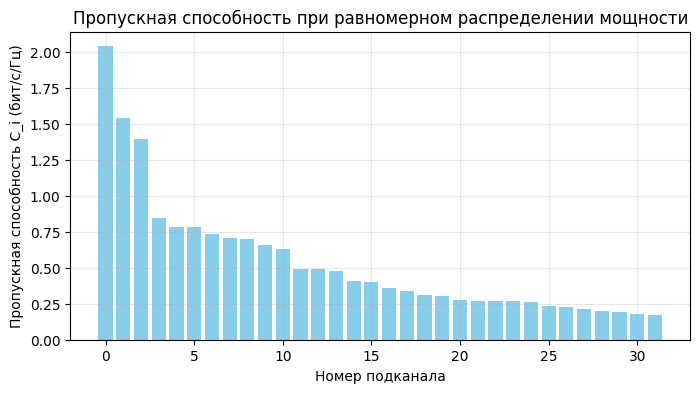

In [75]:
plt.figure(figsize=(8,4))
plt.bar(np.arange(N), C_uniform_per_channel, color="skyblue")
plt.xlabel("Номер подканала")
plt.ylabel("Пропускная способность C_i (бит/с/Гц)")
plt.title("Пропускная способность при равномерном распределении мощности")
plt.grid(True, alpha=0.3)
plt.show()

На графике показана пропускная способность каждого подканала при **равномерном распределении мощности**.

- Слева — «лучшие» каналы (меньший шум σ²), у них наибольшая C_i.
- Справа — «худшие» каналы (большой шум), на них та же мощность даёт заметно меньше бит/с/Гц.
- Суммарная пропускная способность системы равна сумме высот всех столбиков и составляет примерно **17.18 бит/с/Гц**.

Этот график служит **базовой точкой сравнения**:
далее мы будем применять алгоритм water-filling, перераспределять мощность
в пользу «хороших» подканалов и смотреть, как изменится распределение C_i
и суммарная пропускная способность.

Теперь реализуем метод "разлива воды" для оптимального распределения мощности между каналами

In [76]:
def water_filling(sigma2, P_total):
    """
    Реализация алгоритма water-filling.
    
    sigma2 : массив дисперсий шума σ_i^2
    P_total : общий бюджет мощности
    
    Возвращает:
    P_opt : оптимальные мощности P_i*
    mu : уровень воды
    """
    
    N = len(sigma2)
    # сортируем каналы (лучшие → худшие)
    idx = np.argsort(sigma2)
    sigma2_sorted = sigma2[idx]
    
    # Предварительная сумма шумов
    prefix_sum = 0.0
    
    for k in range(1, N+1):
        # Пробуем активировать первые k каналов
        prefix_sum += sigma2_sorted[k-1]
        
        # Вычисляем уровень воды μ для k активных каналов:
        mu = (P_total + prefix_sum) / k
        
        # Проверяем, что μ выше, чем уровень шума у следующего канала
        if k == N or mu <= sigma2_sorted[k]:
            break

    # Теперь распределяем мощности по найденному уровню воды
    P_opt_sorted = np.maximum(0, mu - sigma2_sorted)
    
    # Возвращаем в исходном порядке
    P_opt = np.zeros(N)
    P_opt[idx] = P_opt_sorted
    
    return P_opt, mu

Применим алгоритм к нашим каналам

In [77]:

P_opt, mu = water_filling(sigma2, P_total)

print("Уровень воды μ =", mu)
print("Оптимальные мощности P_i* =", P_opt)
print("Проверка суммы: ", np.sum(P_opt), " (должно быть=", P_total, ")")

Уровень воды μ = 2.309752336982826
Оптимальные мощности P_i* = [2.10888831 1.98214531 1.92514264 1.52623242 1.44537919 1.445261
 1.37418413 1.31881    1.31107024 1.2313508  1.16929069 0.78272955
 0.77824356 0.71896535 0.4145793  0.37450575 0.09322175 0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.        ]
Проверка суммы:  20.0  (должно быть= 20.0 )


Выведем снова пропускную способность каналов, но уже с оптимальным распределением мощности

In [78]:
C_wf_per_channel = np.log2(1 + P_opt / sigma2)
C_wf_total = np.sum(C_wf_per_channel)

print("Пропускная способность по каналам:", C_wf_per_channel)
print("Суммарная пропускная способность (water-filling):", C_wf_total)

Пропускная способность по каналам: [3.52344708 2.81769998 2.58627111 1.55969631 1.418012   1.41781475
 1.30382343 1.22086515 1.20964075 1.09884372 1.01812024 0.59701658
 0.59278453 0.5379975  0.28540859 0.25522077 0.05943489 0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.        ]
Суммарная пропускная способность (water-filling): 21.502097392612324


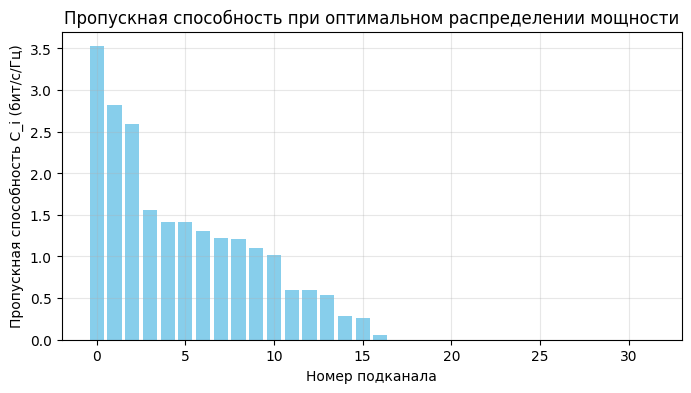

In [79]:
plt.figure(figsize=(8,4))
plt.bar(np.arange(N), C_wf_per_channel, color="skyblue")
plt.xlabel("Номер подканала")
plt.ylabel("Пропускная способность C_i (бит/с/Гц)")
plt.title("Пропускная способность при оптимальном распределении мощности")
plt.grid(True, alpha=0.3)
plt.show()

На графике показана пропускная способность каждого подканала при **оптимальном распределении мощности**.

- Слева — «лучшие» каналы (меньший шум σ²), в них основная часть суммарной пропускной способности.
- Справа — «худшие» каналы (большой шум), на них мощность не распределена и они "выключены".
- Суммарная пропускная способность системы равна сумме высот всех столбиков и составляет примерно **21.5 бит/с/Гц**.

In [80]:
print("Uniform allocation:", C_uniform_total)
print("Water-filling:", C_wf_total)
print("Прирост:", C_wf_total - C_uniform_total)
print("Прирост (%) =", 100 * (C_wf_total - C_uniform_total) / C_uniform_total)

Uniform allocation: 17.179872754902814
Water-filling: 21.502097392612324
Прирост: 4.32222463770951
Прирост (%) = 25.158653381038743


Uniform allocation: 17.179872754902814
Water-filling: 21.502097392612324
Прирост: 4.32222463770951
Прирост (%) = 25.158653381038743


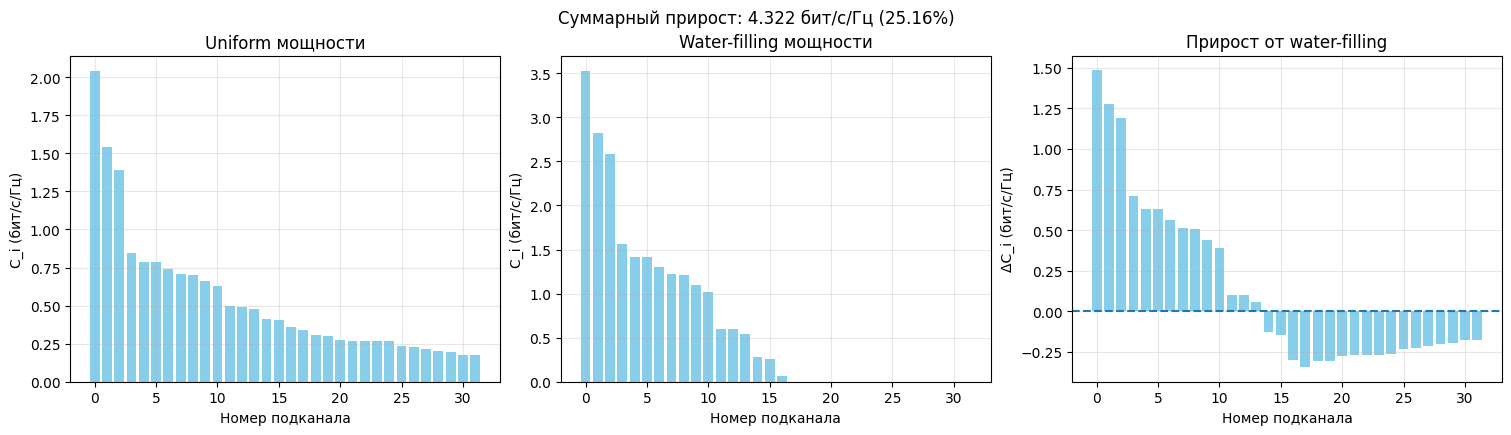

In [81]:
import numpy as np
import matplotlib.pyplot as plt

# Предполагаем, что уже есть:
# N
# C_uniform_per_channel
# C_wf_per_channel
# C_uniform_total
# C_wf_total

gain_total = C_wf_total - C_uniform_total
gain_percent = 100 * gain_total / C_uniform_total
gain_per_channel = C_wf_per_channel - C_uniform_per_channel

print("Uniform allocation:", C_uniform_total)
print("Water-filling:", C_wf_total)
print("Прирост:", gain_total)
print("Прирост (%) =", gain_percent)

# ---------------------------------------------
# Рисуем 3 графика рядом
# ---------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

x = np.arange(N)

# 1) Пропускная способность при равномерном распределении
axes[0].bar(x, C_uniform_per_channel, color="skyblue")
axes[0].set_xlabel("Номер подканала")
axes[0].set_ylabel("C_i (бит/с/Гц)")
axes[0].set_title("Uniform мощности")
axes[0].grid(True, alpha=0.3)

# 2) Пропускная способность при water-filling
axes[1].bar(x, C_wf_per_channel, color="skyblue")
axes[1].set_xlabel("Номер подканала")
axes[1].set_ylabel("C_i (бит/с/Гц)")
axes[1].set_title("Water-filling мощности")
axes[1].grid(True, alpha=0.3)

# 3) Прирост по каждому каналу
axes[2].bar(x, gain_per_channel,color="skyblue")
axes[2].axhline(0, linestyle="--")
axes[2].set_xlabel("Номер подканала")
axes[2].set_ylabel("ΔC_i (бит/с/Гц)")
axes[2].set_title("Прирост от water-filling")
axes[2].grid(True, alpha=0.3)

fig.suptitle(
    f"Суммарный прирост: {gain_total:.3f} бит/с/Гц ({gain_percent:.2f}%)",
    y=1.05
)

plt.show()


Сравнение пропускной способности отдельных подканалов при равномерном распределении мощности и при оптимальном water-filling. 
Алгоритм перераспределяет мощность в пользу «чистых» подканалов (с малым σ²), существенно увеличивая их пропускную способность, 
и практически отключает самые шумные подканалы, где прирост скорости на единицу мощности минимален. 

На левом графике показаны Cᵢ при равномерном распределении мощности.  
В центре — Cᵢ при water-filling и суммарный прирост пропускной способности (+25%).  
Правый график показывает вклад каждого подканала: лучшие каналы дают значительный выигрыш, 
а худшие — наоборот, становятся неактивными, что экономит мощность и повышает общую эффективность системы.


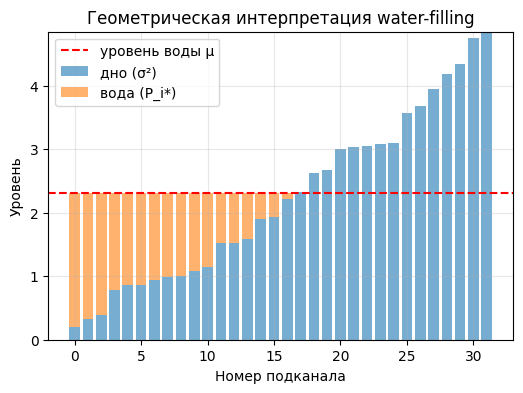

In [82]:
x = np.arange(N)

plt.figure(figsize=(6,4))
plt.bar(x, sigma2, label="дно (σ²)", alpha=0.6)
plt.bar(x, P_opt, bottom=sigma2, label="вода (P_i*)", alpha=0.6)
plt.axhline(mu, color="red", linestyle="--", label="уровень воды μ")

plt.xlabel("Номер подканала")
plt.ylabel("Уровень")
plt.title("Геометрическая интерпретация water-filling")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


На графике показано:

- голубые нижние столбики — "дно" каналов, то есть уровни шума σ_i²;
- поверх них — светлые столбики мощности P_i*, которые "налил" алгоритм water-filling;
- пунктирная линия — общий уровень воды μ.

Хорошо видно, что:

- "глубокие" каналы (с низким σ²) получают больше мощности,
- самые "мелкие" и шумные каналы (у которых σ² выше уровня μ) вообще не заполняются (P_i* = 0) и по сути **отключаются**,
- при том же общем бюджете мощности такая конфигурация даёт максимальную суммарную пропускную способность.

Этот график — наглядная иллюстрация того, как теоретический алгоритм water-filling реализует идею:
**"сначала кормим лучшие каналы, а совсем плохие можем не использовать вообще"**.

Реализуем алгоритм адаптивной модуляции (AMC) для равномерного и оптимального рспределения мощности и посмотрим, насколько изменится количество информации в одном символе

In [83]:
def choose_modulation(snr_db):
    """
    Очень грубая таблица соответствия:
      snr_db <   0 дБ  -> BPSK  (1 бит/символ)
      0–10 дБ        -> QPSK  (2 бита/символ)
      10–20 дБ       -> 16-QAM (4 бита/символ)
      >20 дБ         -> 64-QAM (6 бит/символ)
    """
    if snr_db < 0:
        return "BPSK", 1
    elif snr_db < 10:
        return "QPSK", 2
    elif snr_db < 20:
        return "16-QAM", 4
    else:
        return "64-QAM", 6


# SNR для каждого подканала при двух вариантах распределения мощности
SNR_uniform = P_uniform / sigma2          # линейная шкала
SNR_wf      = P_opt     / sigma2

SNR_uniform_db = 10 * np.log10(SNR_uniform + 1e-12)  # подстрахуемся от деления на 0
SNR_wf_db      = 10 * np.log10(SNR_wf      + 1e-12)

mods_uniform = []
mods_wf = []
bits_per_symbol_uniform = []
bits_per_symbol_wf = []

for i in range(N):
    m_u, b_u = choose_modulation(SNR_uniform_db[i])
    m_w, b_w = choose_modulation(SNR_wf_db[i])
    
    mods_uniform.append(m_u)
    mods_wf.append(m_w)
    bits_per_symbol_uniform.append(b_u)
    bits_per_symbol_wf.append(b_w)

bits_per_symbol_uniform = np.array(bits_per_symbol_uniform)
bits_per_symbol_wf      = np.array(bits_per_symbol_wf)

# Сколько бит несёт один OFDM-символ (если все подканалы активны)
total_bits_uniform = np.sum(bits_per_symbol_uniform)
total_bits_wf      = np.sum(bits_per_symbol_wf)

print("Биты на OFDM-символ при uniform:", total_bits_uniform)
print("Биты на OFDM-символ при water-filling:", total_bits_wf)
print("Прирост по битам/символ:", total_bits_wf - total_bits_uniform)
print("Прирост по битам/символ (%):", 100 * (total_bits_wf - total_bits_uniform) / total_bits_uniform)


Биты на OFDM-символ при uniform: 35
Биты на OFDM-символ при water-filling: 45
Прирост по битам/символ: 10
Прирост по битам/символ (%): 28.571428571428573


Изобразим на графике, сколько бит на каждом подканале

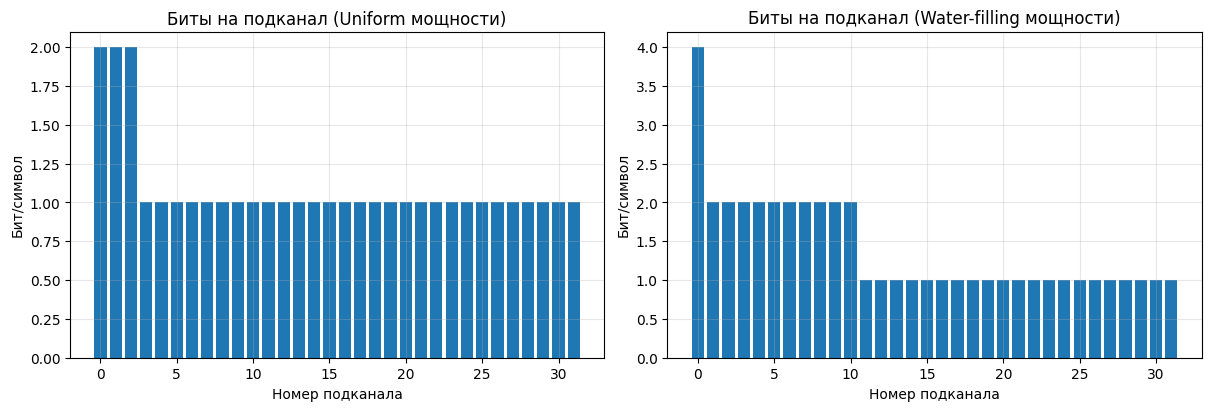

In [84]:

x = np.arange(N)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# Биты на подканал при uniform
axes[0].bar(x, bits_per_symbol_uniform)
axes[0].set_xlabel("Номер подканала")
axes[0].set_ylabel("Бит/символ")
axes[0].set_title("Биты на подканал (Uniform мощности)")
axes[0].grid(True, alpha=0.3)

# Биты на подканал при water-filling
axes[1].bar(x, bits_per_symbol_wf)
axes[1].set_xlabel("Номер подканала")
axes[1].set_ylabel("Бит/символ")
axes[1].set_title("Биты на подканал (Water-filling мощности)")
axes[1].grid(True, alpha=0.3)

plt.show()


Здесь мы добавили простой алгоритм адаптивной модуляции (AMC):

- для каждого подканала считаем SNR (при uniform и при water-filling);
- по SNR в дБ выбираем схему модуляции: BPSK / QPSK / 16-QAM / 64-QAM;
- переводим это в число бит на символ на каждом подканале;
- суммируем по всем подканалам и получаем, сколько бит несёт один OFDM-символ.

В нашем эксперименте получилось:

- **биты на OFDM-символ при uniform:** 35  
- **биты на OFDM-символ при water-filling:** 45  
- **прирост:** 10 бит/символ, что соответствует примерно **28.6%**.

То есть при том же общем бюджете мощности оптимальное распределение (water-filling) позволяет
использовать более высокие модуляции на «хороших» подканалах и, как результат,
каждый OFDM-символ переносит значительно больше информации, чем при равномерном распределении мощности.



## **Результаты и применимость**

#### **Краткие выводы экспериментов**

- При равномерном распределении мощности часть энергии тратится на подканалы с высоким уровнем шума, где прирост пропускной способности на единицу мощности минимален. Это приводит к тому, что система работает далеко не оптимально.

- Алгоритм **water-filling** перераспределяет мощность в пользу «глубоких» (малошумящих) подканалов и может полностью отключать самые «мелкие» (шумные). На графике «дно + вода» это выражается в том, что некоторые каналы вообще не получают мощности, если их уровень шума превышает уровень воды μ.

- Для заданного набора каналов мы получили существенный выигрыш в суммарной пропускной способности:  
  **+4.322 бит/с/Гц**, что составляет **≈25.16% прироста** по сравнению с равномерной схемой.

- Анализ пропускной способности по каждому подканалу показывает, что основной вклад дают лучшие каналы, где при увеличении мощности логарифмический прирост  
  $$
  C_i = \log_2\left(1 + \frac{P_i}{\sigma_i^2}\right)
  $$ 
  наиболее эффективен. Худшие каналы, наоборот, становятся неактивными.

- Добавление схемы адаптивной модуляции (AMC) усиливает эффект:  
  при равномерном распределении один OFDM-символ несёт **35 бит**,  
  при water-filling — **45 бит**,  
  что даёт **+28.6% прироста информации на символ**.

---

#### **Как это можно использовать**

- **Распределение мощности в OFDM / многотональных системах.**  
  Water-filling — фундаментальный механизм оптимального распределения мощности между поднесущими. Он лежит в основе адаптивных схем в DSL, LTE/5G, Wi-Fi и других широкополосных системах.

- **Адаптивная модуляция и кодирование (AMC).**  
  Повышение SNR на «хороших» подканалах позволяет использовать более высокие модуляции (QPSK → 16QAM → 64QAM), увеличивая количество передаваемых бит на OFDM-символ. Water-filling — оптимальный способ «выкроить» необходимый SNR там, где он даст максимальный выигрыш.

- **Отключение «плохих» подканалов.**  
  Если шумовой уровень слишком велик (σ² выше уровня μ), поддерживать такой подканал активным экономически бессмысленно. Water-filling автоматически «отключает» такие каналы, перераспределяя мощность в пользу полезных частот.

- **Инженерное планирование и оценка спектральной эффективности.**  
  Модель показывает, что значительный выигрыш появляется в условиях сильной неоднородности канала и ограниченной мощности — типичная ситуация в реальных системах связи.

- **Понимание теоретического предела.**  
  Water-filling — это точное решение задачи максимизации пропускной способности параллельных AWGN-каналов. Оно задаёт верхнюю границу эффективности, к которой стремятся реальные системы связи при адаптации мощности, модуляции и кодирования.

## **Литература**

1. [Статья на Хабр (JetBrains Education) о теореме Шеннона–Хартли](https://habr.com/ru/companies/JetBrains-education/articles/599637/)
2. [Теорема Шеннона — Хартли (Wikipedia)](https://ru.wikipedia.org/wiki/Теорема_Шеннона_—_Хартли)
3. [Аддитивный белый гауссовский шум (Wikipedia)](https://ru.wikipedia.org/wiki/Аддитивный_белый_гауссовский_шум)
4. [Спектральная плотность мощности (Wikipedia)](https://ru.wikipedia.org/wiki/Спектральная_плотность_мощности)
6. [Пропускная способность канала (Wikipedia)](https://ru.wikipedia.org/wiki/Пропускная_способность_канала)
7. [Отношение сигнал/шум (Wikipedia)](https://ru.wikipedia.org/wiki/Eb/N0)
8. [Пропускная способность канала (Wikipedia)](https://ru.wikipedia.org/wiki/Пропускная_способность_канала)

9. [CDMA: борьба с замираниями](https://www.osp.ru/nets/2000/09/141359)
10. [Алгоритм водонаполнения](https://en.wikipedia.org/wiki/Water-filling_algorithm)
11. [Метод множителей Лагранжа](https://ru.wikipedia.org/wiki/Метод_множителей_Лагранжа)
12. [OFDM - Orthogonal frequency-division multiplexing](https://ru.wikipedia.org/wiki/OFDM)


